# Experimental setup

Set up for the experiment. This will load in the required packages, load in the data set, and load in the model. Then the experiment is run on the data set, saving the model weights and the results so they can be reloaded later. Below are the returned metrics.

## Metrics

- Overall performance in learned tasks: Usually average accuracy and average incremental accuracy, and confusion matrix
- Memory stability of old classes: uses forgetting measure (average forgetting of old tasks) and backward transfer (average influence of learning the k-th task on all old tasks)
- Learning plasticity of new classes: intransience measure (inability to learn a new task) and forward transfer (average influence of all old tasks on the current task)
- Resource (storage) and computational overheads (big O complexity), RAM usage.
- Discrepancy of task distribution

In [ ]:
#TODO:

## Imports

In [8]:
# Load packages
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import transforms

# model and dataset factories
from models_classes.convnext import create_convnext
from dataset_classes.imagenette import ImagenetteContinual
from dataset_classes.cifar import CIFAR10Continual
from dataset_classes.cifar_small import CIFAR10SmallContinual

import numpy as np
import matplotlib.pyplot as plt

import os
import time

from collections import defaultdict

print(torch.__version__)
print(torch.cuda.is_available())
torch.set_default_device('cuda')

2.10.0+cu128
True


In [9]:
# Parameters

LOAD_FROM_FILE = False
FILE_LOAD_PATH = os.path.join(os.getcwd(), 'models', 'model_weights.pth')

TEST_INTERVAL = 'class' # Can be 'class', 'batch', or None.
TEST_EVERY_N = 100 # Number of batches between tests, only used if TEST_INTERVAL='batch'

# Debug: use a tiny CIFAR-10 subset for very fast script debugging runs
DEBUG_USE_SMALL_CIFAR = True
DEBUG_SAMPLES_PER_CLASS_TRAIN = 5
DEBUG_SAMPLES_PER_CLASS_TEST = 5
DEBUG_RANDOM_SEED = 42

# Whether to compute measures that require training a separate reference/joint model
# (intranscience measure and forward transfer). Training a joint reference can be
# expensive; set to True only when you want the extra baselines computed.
COMPUTE_REFERENCE_BASELINES = False

REFERENCE_TRAIN_EPOCHS = 1  # epochs to train the joint/reference model when enabled
REFERENCE_BATCH_SIZE = 64   # batch size used for joint/reference training


In [10]:
# Check for necessary output folders

folder_path = os.path.join(os.getcwd(), 'datasets')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'results')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Load dataset and model via dataset_classes / models_classes
dataset_path = os.path.join(os.getcwd(), 'datasets')

download = not (os.path.exists(dataset_path))

print('Downloading dataset:',download)

print('Dataset path:', dataset_path)

# Define the desired size for the input tensors (can be overridden by dataset class)
desired_size = (224, 224)

# Instantiate dataset manager (small CIFAR-10 for debug or full CIFAR-10)
if DEBUG_USE_SMALL_CIFAR:
    dataset_manager = CIFAR10SmallContinual(root=dataset_path, desired_size=desired_size, download=True,
                                           batch_size=1, num_workers=0,
                                           samples_per_class_train=DEBUG_SAMPLES_PER_CLASS_TRAIN,
                                           samples_per_class_test=DEBUG_SAMPLES_PER_CLASS_TEST,
                                           seed=DEBUG_RANDOM_SEED)
else:
    # (previously used Imagenette — use ImagenetteContinual(...) if you want that dataset)
    dataset_manager = CIFAR10Continual(root=dataset_path, desired_size=desired_size, download=True, batch_size=1, num_workers=0)

# expose the same variables used by the rest of the notebook
dataset_train = dataset_manager.train_dataset
dataset_test = dataset_manager.test_dataset
class_to_indices_train = dataset_manager.class_to_indices_train
class_to_indices_test = dataset_manager.class_to_indices_test
class_order_train = dataset_manager.class_order_train
class_order_test = dataset_manager.class_order_test

train_dataloader = dataset_manager.train_dataloader

test_dataloader = dataset_manager.test_dataloader

# Build model using model factory
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pkg = create_convnext(num_classes=len(class_order_train), device=device, lr=1e-3, pretrained=False)
model = model_pkg['model']
loss_fn = model_pkg['loss_fn']
optimizer = model_pkg['optimizer']
train = model_pkg['train_fn']
test = model_pkg['test_fn']
backward_fn = model_pkg['backward_fn']
model_name = model_pkg.get('name', 'convnext_tiny')
model_params = model_pkg.get('default_params', {})
print(f"Using {device} device")
print(model)

Dataset path: c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\datasets
Using cuda device
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()

In [7]:
# Create training metaparameters

loss_fn = nn.CrossEntropyLoss()
# optimizer is model-specific and provided by the model factory (model_pkg['optimizer'])
# (model_pkg created in the dataset/model setup cell)

epochs = 1 # required for continual online learning to be 1

In [11]:
# Use train/test provided by the model package (model_pkg['train_fn'], model_pkg['test_fn'])
# These model-specific implementations are compatible with the remainder of the notebook.
train = model_pkg['train_fn']
test = model_pkg['test_fn']

# (loss_fn and optimizer are provided/overwritten above from the model factory if needed)

In [12]:
# Training

# Option 1: Test after each class
if TEST_INTERVAL == 'class':
    train_metrics, test_history, class_change_steps = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='class')

# Option 2: Test every N batches

elif TEST_INTERVAL == 'batch':
    train_metrics, test_history, class_change_steps = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='batch', test_every_n=TEST_EVERY_N)

# Option 3: No intermediate testing

else:
    test_history = []
    class_change_steps = []
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)
        test_result = test(test_dataloader, model, loss_fn)
        test_result['step'] = t + 1
        test_result['step_type'] = 'epoch'
        test_history.append(test_result)

##################

print("Done!")

timestr = time.strftime("%Y%m%d-%H%M%S")

# Save metadata + metrics so experiments are reproducible
metadata = {
    'dataset_name': getattr(dataset_manager, 'name', None),
    'dataset_params': dataset_manager.to_dict() if hasattr(dataset_manager, 'to_dict') else {},
    'model_name': model_name,
    'model_params': model_params,
    'training_params': {
        'epochs': epochs,
        'test_interval': TEST_INTERVAL,
        'test_every_n': TEST_EVERY_N,
        'compute_reference_baselines': COMPUTE_REFERENCE_BASELINES
    }
}

metrics_save = {
    'metadata': metadata,
    'test_history': test_history,
    'train_metrics': train_metrics if 'train_metrics' in globals() else None
}

metrics_path = os.path.join(os.getcwd(), 'results', timestr + '_train_metrics.pth')
torch.save(metrics_save, metrics_path)
print(f"Saved training metrics and metadata to {metrics_path}")

# save model weights along with metadata
model_save_path = os.path.join(os.getcwd(), 'models', timestr + '_model_weights.pth')
torch.save({'state_dict': model.state_dict(), 'metadata': metadata}, model_save_path)
print(f"Saved PyTorch Model State to {model_save_path}")

Starting training on Class 0
  Class 0 - Processed 5 samples, Avg loss: 0.557545
  Testing after Class 0:
Testing on Class 0
  Class 0 - Accuracy: 100.0%, Avg loss: 0.056870
Testing on Class 1
  Class 1 - Accuracy: 0.0%, Avg loss: 4.888808
Testing on Class 2
  Class 2 - Accuracy: 0.0%, Avg loss: 5.567393
Testing on Class 3
  Class 3 - Accuracy: 0.0%, Avg loss: 4.953251
Testing on Class 4
  Class 4 - Accuracy: 0.0%, Avg loss: 5.119374
Testing on Class 5
  Class 5 - Accuracy: 0.0%, Avg loss: 4.859844
Testing on Class 6
  Class 6 - Accuracy: 0.0%, Avg loss: 5.130083
Testing on Class 7
  Class 7 - Accuracy: 0.0%, Avg loss: 5.123623
Testing on Class 8
  Class 8 - Accuracy: 0.0%, Avg loss: 4.890356
Testing on Class 9
  Class 9 - Accuracy: 0.0%, Avg loss: 5.720741

Test Summary:
  Overall Accuracy: 10.0%
  Average Task Accuracy: 10.0%
  Overall Avg Loss: 4.631034

Starting training on Class 1
  Class 1 - Processed 5 samples, Avg loss: 1.122577
  Testing after Class 1:
Testing on Class 0
  Cla

CONTINUAL LEARNING EVALUATION METRICS

1. FINAL PERFORMANCE METRICS
--------------------------------------------------------------------------------
Overall Accuracy: 10.00%
Average Task Accuracy: 10.00%
Overall Average Loss: 4.102948

Per-Class Accuracy:
  Class 0: 0.00%
  Class 1: 0.00%
  Class 2: 0.00%
  Class 3: 0.00%
  Class 4: 0.00%
  Class 5: 0.00%
  Class 6: 0.00%
  Class 7: 0.00%
  Class 8: 0.00%
  Class 9: 100.00%

2. CONTINUAL LEARNING METRICS (from Survey)
--------------------------------------------------------------------------------
Average Incremental Accuracy (AIA) - final step: 10.00%
Forgetting measure (FM): 100.00%
Backward Transfer (BWT): -100.00%

IM / FWT disabled — set COMPUTE_REFERENCE_BASELINES = True at the top of the notebook to enable

3. CONFUSION MATRIX
--------------------------------------------------------------------------------


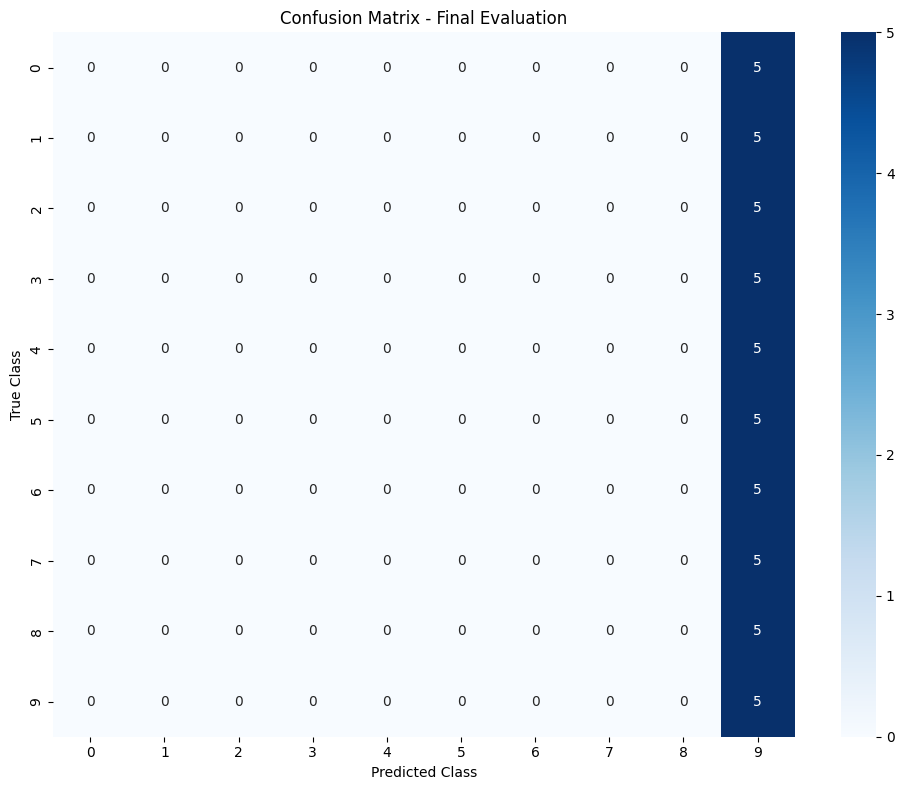


Confusion Matrix (rows: true class, columns: predicted class)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

4. METRICS OVER TIME
--------------------------------------------------------------------------------


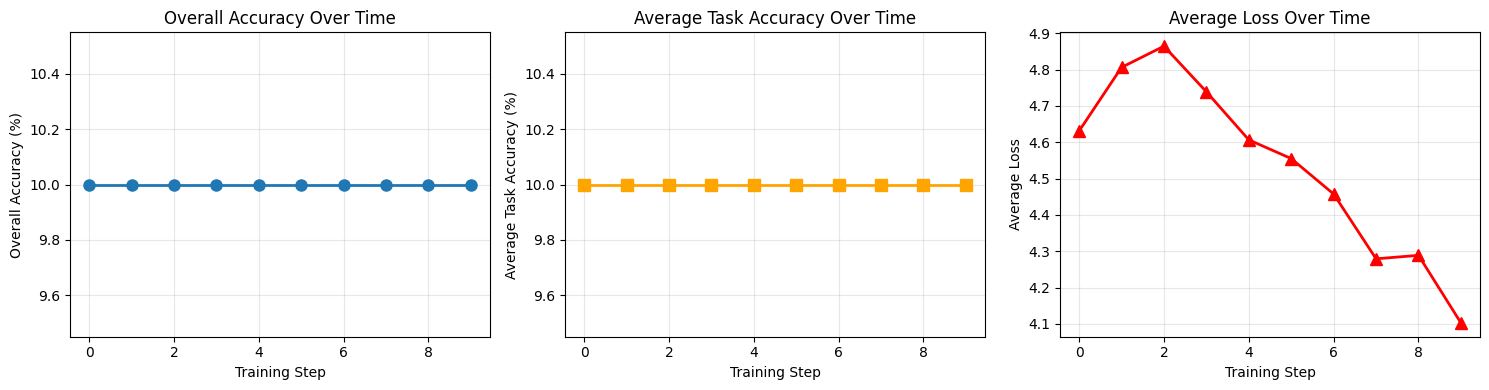

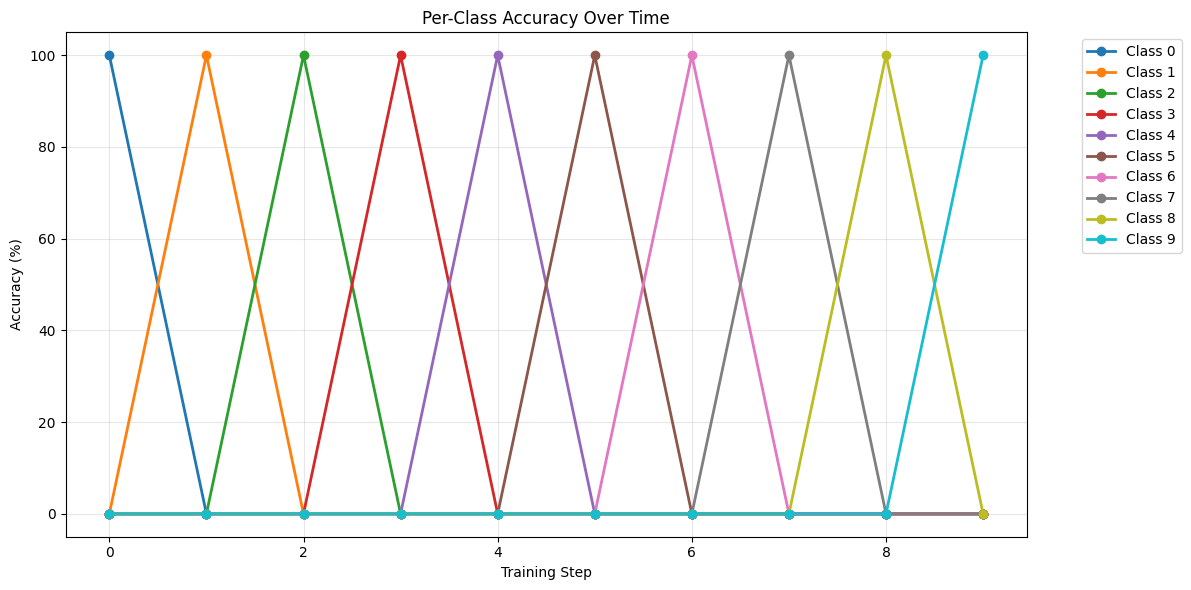

In [13]:
# Metrics and plots
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
import seaborn as sns

print("=" * 80)
print("CONTINUAL LEARNING EVALUATION METRICS")
print("=" * 80)

# --- Safe helpers ---------------------------------------------------------
def safe_get_per_class(test_result, cls):
    return test_result.get('overall', {}).get('per_class_accuracies', {}).get(cls, np.nan)

# Extract final test metrics (if available)
final_test_result = test_history[-1] if test_history else {}
final_overall = final_test_result.get('overall', {})
per_class_acc = final_overall.get('per_class_accuracies', {})
confusion_mat = final_overall.get('confusion_matrix', {})

print("\n1. FINAL PERFORMANCE METRICS")
print("-" * 80)
print(f"Overall Accuracy: {final_overall.get('accuracy', 0):>0.2f}%")
print(f"Average Task Accuracy: {final_overall.get('average_task_accuracy', 0):>0.2f}%")
print(f"Overall Average Loss: {final_overall.get('avg_loss', 0):>8f}")

print("\nPer-Class Accuracy:")
for cls in sorted(per_class_acc.keys()):
    print(f"  Class {cls}: {per_class_acc[cls]:>0.2f}%")

# -------------------------------------------------------------------------
# Build accuracy matrix R where R[k, j] is accuracy on task j after learning task k
# Rows: test steps (in order of test_history). Columns: class labels (sorted).
# Missing values are filled with np.nan so downstream calculations can ignore them.
# -------------------------------------------------------------------------
all_classes = sorted({
    cls for t in test_history for cls in t.get('overall', {}).get('per_class_accuracies', {}).keys()
}) if test_history else []

num_steps = len(test_history)
num_tasks = len(all_classes)

# For batch mode, mark class changes and still build R by class
if num_steps > 0 and num_tasks > 0:
    class_to_col = {c: i for i, c in enumerate(all_classes)}
    R = np.full((num_steps, num_tasks), np.nan)
    for step_idx, t in enumerate(test_history):
        for cls, acc in t.get('overall', {}).get('per_class_accuracies', {}).items():
            R[step_idx, class_to_col[cls]] = acc
else:
    R = np.empty((0, 0))

# 2. CONTINUAL-LEARNING METRICS (AIA, BWT, FM, IM, FWT)
print("\n2. CONTINUAL LEARNING METRICS (from Survey)")
print("-" * 80)

# Average Incremental Accuracy (AIA): for step k, average_j<=k R[k,j]
aia_per_step = []
if R.size:
    for k in range(R.shape[0]):
        row = R[k, :k+1]  # j <= k
        aia_per_step.append(np.nanmean(row))
    aia_final = aia_per_step[-1]
    print(f"Average Incremental Accuracy (AIA) - final step: {aia_final:>0.2f}%")
else:
    print("Average Incremental Accuracy (AIA): not available (no test history)")

# Backward Transfer (BWT) and Forgetting Measure (FM)
if R.size and R.shape[0] > 1:
    final_row = R[-1, :]
    diag = np.array([R[i, i] for i in range(min(R.shape[0], R.shape[1]))])

    # Only consider tasks up to the current task minus one
    max_task = min(R.shape[0], R.shape[1]) - 1  # up to T-2 if T tasks
    if max_task > 0:
        valid_idx = [i for i in range(max_task) if (not np.isnan(diag[i]) and not np.isnan(final_row[i]))]
        if valid_idx:
            forgetting_vals = [diag[i] - final_row[i] for i in valid_idx]
            fm = np.mean(forgetting_vals)
            # BWT as average (final - initially observed after task learning)
            bwt_vals = [final_row[i] - diag[i] for i in valid_idx]
            bwt = np.mean(bwt_vals)
            print(f"Forgetting measure (FM): {fm:>0.2f}%")
            print(f"Backward Transfer (BWT): {bwt:>0.2f}%")
        else:
            print("FM / BWT: insufficient per-task accuracies to compute")
    else:
        print("FM / BWT: not enough tasks to compute (need at least two tasks)")
else:
    print("FM / BWT: not available (need at least two test steps and per-class accuracies)")

# Optional: Intranscience Measure (IM) and Forward Transfer (FWT)
# These require a reference/joint baseline model (COMPUTE_REFERENCE_BASELINES flag).
if COMPUTE_REFERENCE_BASELINES:
    print("\nComputing per-class reference baselines (fresh model per class, single pass)...")

    # train a fresh model for each class using a single-pass (one epoch over that class'
    # training split) to match the continual learner's single-pass behaviour.
    gen_device = getattr(device, 'type', 'cpu')
    gen = torch.Generator(device=gen_device)

    per_class_acc = {}

    for cls in all_classes:
        indices = class_to_indices_train.get(cls, [])
        if not indices:
            per_class_acc[cls] = np.nan
            continue

        # Subset the training dataset to this class only
        class_train_subset = torch.utils.data.Subset(dataset_train, indices)
        class_train_loader = torch.utils.data.DataLoader(class_train_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=True, num_workers=0, generator=gen)

        # Fresh model for this class
        ref_model_c = torchvision.models.convnext_tiny()
        ref_model_c.to(device)
        ref_loss = nn.CrossEntropyLoss()
        ref_optimizer = torch.optim.SGD(ref_model_c.parameters(), lr=1e-3)

        # Single pass over the class training data (match continual single-pass)
        ref_model_c.train()
        epoch_loss = 0.0
        for X, y in class_train_loader:
            X, y = X.to(device), y.to(device)
            pred = ref_model_c(X)
            loss = ref_loss(pred, y)
            loss.backward()
            ref_optimizer.step()
            ref_optimizer.zero_grad()
            epoch_loss += loss.item()
        # optional: print per-class training summary
        print(f"  Trained ref model for class {cls} (single pass), avg loss: {epoch_loss/len(class_train_loader):.4f}")

        # Evaluate this fresh model on the test split of the same class
        test_indices = class_to_indices_test.get(cls, [])
        if not test_indices:
            per_class_acc[cls] = np.nan
            continue

        class_test_subset = torch.utils.data.Subset(dataset_test, test_indices)
        class_test_loader = torch.utils.data.DataLoader(class_test_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=False, num_workers=0, generator=gen)

        ref_model_c.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in class_test_loader:
                X, y = X.to(device), y.to(device)
                preds = ref_model_c(X)
                pred_labels = preds.argmax(1)
                correct += (pred_labels == y).sum().item()
                total += y.size(0)
        per_class_acc[cls] = 100.0 * correct / max(1, total)

    # Expose per-class reference accuracies under the same name used downstream
    joint_per_class_acc = {cls: per_class_acc.get(cls, np.nan) for cls in all_classes}

    # Save per-class reference results
    timestr_ref = time.strftime("%Y%m%d-%H%M%S")
    ref_save_path = os.path.join(os.getcwd(), 'results', timestr_ref + '_per_class_reference.pth')
    torch.save({'joint_per_class_acc': joint_per_class_acc}, ref_save_path)
    print(f"Saved per-class reference baselines to {ref_save_path} (model weights not saved)")
    # Intranscience (IM): joint_acc - continual_final_acc (average across tasks)
    im_list = []
    for idx, cls in enumerate(all_classes):
        joint_acc = joint_per_class_acc.get(cls, np.nan)
        cl_final_acc = R[-1, idx] if R.size and idx < R.shape[1] else np.nan
        if not np.isnan(joint_acc) and not np.isnan(cl_final_acc):
            im_list.append(joint_acc - cl_final_acc)
    if im_list:
        im = np.mean(im_list)
        print(f"Intranscience measure (IM): {im:>0.2f}%")
    else:
        print("Intranscience (IM): insufficient data to compute")

    # Forward Transfer (FWT): average over k>1 of (R[k-1,k] - joint_acc_k)
    fwt_list = []
    if R.size and R.shape[0] > 1:
        # class order in test_history rows matches 'all_classes' columns mapping
        for k in range(1, R.shape[0]):
            # current task column is the same index as row 'k' only if classes and steps align
            if k < R.shape[1]:
                prior_acc = R[k-1, k]
                baseline = joint_per_class_acc.get(all_classes[k], np.nan)
                if not np.isnan(prior_acc) and not np.isnan(baseline):
                    fwt_list.append(prior_acc - baseline)
    if fwt_list:
        fwt = np.mean(fwt_list)
        print(f"Forward Transfer (FWT): {fwt:>0.2f}%")
    else:
        print("Forward Transfer (FWT): insufficient data to compute")

else:
    print("\nIM / FWT disabled — set COMPUTE_REFERENCE_BASELINES = True at the top of the notebook to enable")


# Confusion Matrix Visualization
if confusion_mat:
    print("\n3. CONFUSION MATRIX")
    print("-" * 80)

    # Convert confusion matrix dict to numpy array
    all_classes_conf = sorted(set(
        list(confusion_mat.keys()) +
        [item for subdict in confusion_mat.values() for item in subdict.keys()]
    ))

    cm_array = np.zeros((len(all_classes_conf), len(all_classes_conf)))
    for true_cls in confusion_mat:
        for pred_cls in confusion_mat[true_cls]:
            true_idx = all_classes_conf.index(true_cls)
            pred_idx = all_classes_conf.index(pred_cls)
            cm_array[true_idx, pred_idx] = confusion_mat[true_cls][pred_cls]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues', 
                xticklabels=all_classes_conf, yticklabels=all_classes_conf)
    plt.title('Confusion Matrix - Final Evaluation')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

    print("\nConfusion Matrix (rows: true class, columns: predicted class)")
    print(f"Classes: {all_classes_conf}")

# Metrics Over Time
if len(test_history) > 1:
    print("\n4. METRICS OVER TIME")
    print("-" * 80)

    overall_accs = [t.get('overall', {}).get('accuracy', 0) for t in test_history]
    avg_task_accs = [t.get('overall', {}).get('average_task_accuracy', 0) for t in test_history]
    avg_losses = [t.get('overall', {}).get('avg_loss', 0) for t in test_history]

    steps = [t.get('step', i) for i, t in enumerate(test_history)]

    # Plot metrics over time
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Overall Accuracy
    axes[0].plot(steps, overall_accs, marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Overall Accuracy (%)')
    axes[0].set_title('Overall Accuracy Over Time')
    axes[0].grid(True, alpha=0.3)

    # Average Task Accuracy
    axes[1].plot(steps, avg_task_accs, marker='s', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Average Task Accuracy (%)')
    axes[1].set_title('Average Task Accuracy Over Time')
    axes[1].grid(True, alpha=0.3)

    # Average Loss
    axes[2].plot(steps, avg_losses, marker='^', linewidth=2, markersize=8, color='red')
    axes[2].set_xlabel('Training Step')
    axes[2].set_ylabel('Average Loss')
    axes[2].set_title('Average Loss Over Time')
    axes[2].grid(True, alpha=0.3)

    # Mark class changes on all plots if in batch mode
    if TEST_INTERVAL == 'batch' and 'class_change_steps' in globals():
        for ax in axes:
            for cc in class_change_steps:
                ax.axvline(x=cc, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Per-class accuracy over time
    fig, ax = plt.subplots(figsize=(12, 6))

    if R.size:
        for col_idx, cls in enumerate(all_classes):
            steps_for_class = list(range(R.shape[0]))
            accs_for_class = [R[s, col_idx] for s in steps_for_class]
            ax.plot(steps_for_class, accs_for_class, marker='o', label=f'Class {cls}', linewidth=2)
    else:
        for cls in sorted({c for t in test_history for c in t.get('overall', {}).get('per_class_accuracies', {}).keys()}):
            steps_for_class = []
            accs_for_class = []
            for s_idx, t in enumerate(test_history):
                acc = t.get('overall', {}).get('per_class_accuracies', {}).get(cls, np.nan)
                steps_for_class.append(s_idx)
                accs_for_class.append(acc)
            ax.plot(steps_for_class, accs_for_class, marker='o', label=f'Class {cls}', linewidth=2)

    ax.set_xlabel('Training Step')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy Over Time')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

    # Mark class changes on per-class plot if in batch mode
    if TEST_INTERVAL == 'batch' and 'class_change_steps' in globals():
        for cc in class_change_steps:
            ax.axvline(x=cc, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()